# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API

## Problem Statement & Objective
Customer churn (a customer canceling their subscription) is costly for subscription businesses. This notebook builds a **reusable, production-ready ML pipeline** that predicts whether a Telco customer will churn, using scikit-learn's `Pipeline` and `ColumnTransformer` APIs so preprocessing and modeling are bundled into a single exportable artifact.

**Dataset:** [Telco Customer Churn Dataset](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv) — 7,043 customers, 20 features + churn label.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

## Dataset Loading & Preprocessing

In [2]:
DATA_PATH = "data/Telco-Customer-Churn.csv"
TARGET = "Churn"

df = pd.read_csv(DATA_PATH)
df.drop(columns=["customerID"], inplace=True)
# TotalCharges has some blank strings for brand-new customers; coerce to numeric (-> NaN, imputed later)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df[TARGET] = df[TARGET].map({"Yes": 1, "No": 0})

print(df.shape)
df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


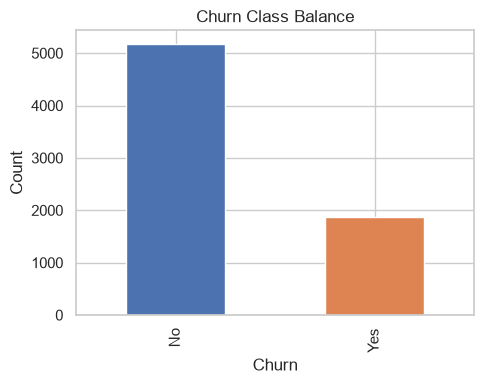

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
df[TARGET].map({0: "No", 1: "Yes"}).value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Churn Class Balance")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [4]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "str"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])
print(f"{len(numeric_cols)} numeric cols, {len(categorical_cols)} categorical cols")

4 numeric cols, 15 categorical cols


## Model Development & Training
Two classifiers — Logistic Regression and Random Forest — are trained end-to-end through the *same* preprocessing pipeline, with hyperparameters tuned via `GridSearchCV` (5-fold CV, scored on F1).

In [5]:
models = {
    "logistic_regression": (
        LogisticRegression(max_iter=1000),
        {"classifier__C": [0.1, 1.0, 10.0], "classifier__solver": ["lbfgs", "liblinear"]},
    ),
    "random_forest": (
        RandomForestClassifier(random_state=42),
        {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [None, 10, 20],
            "classifier__min_samples_split": [2, 5],
        },
    ),
}

results = {}
best_overall, best_overall_score, best_overall_name = None, -1, None

for name, (estimator, param_grid) in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", estimator)])
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1)
    grid.fit(X_train, y_train)

    preds = grid.predict(X_test)
    proba = grid.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    results[name] = {"accuracy": acc, "f1": f1, "roc_auc": auc, "best_params": grid.best_params_,
                      "estimator": grid.best_estimator_, "preds": preds, "proba": proba}
    print(f"{name}: best_params={grid.best_params_}")
    print(f"{name}: accuracy={acc:.4f} f1={f1:.4f} roc_auc={auc:.4f}\n")

    if f1 > best_overall_score:
        best_overall_score, best_overall, best_overall_name = f1, grid.best_estimator_, name

print(f"Best model: {best_overall_name} (f1={best_overall_score:.4f})")

logistic_regression: best_params={'classifier__C': 10.0, 'classifier__solver': 'liblinear'}
logistic_regression: accuracy=0.8048 f1=0.6032 roc_auc=0.8411



random_forest: best_params={'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
random_forest: accuracy=0.7999 f1=0.5778 roc_auc=0.8385

Best model: logistic_regression (f1=0.6032)


## Evaluation

In [6]:
print(classification_report(y_test, results[best_overall_name]["preds"]))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## Visualizations

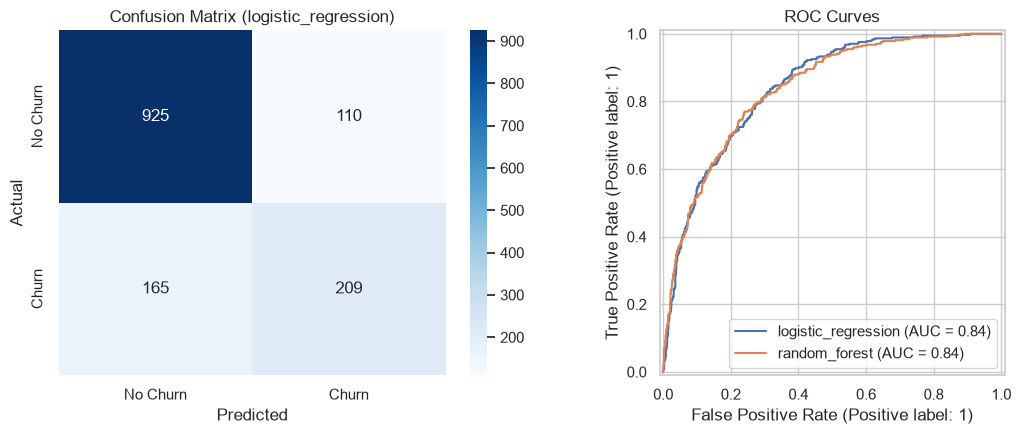

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, results[best_overall_name]["preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
axes[0].set_title(f"Confusion Matrix ({best_overall_name})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res["proba"], name=name, ax=axes[1])
axes[1].set_title("ROC Curves")

plt.tight_layout()
plt.show()

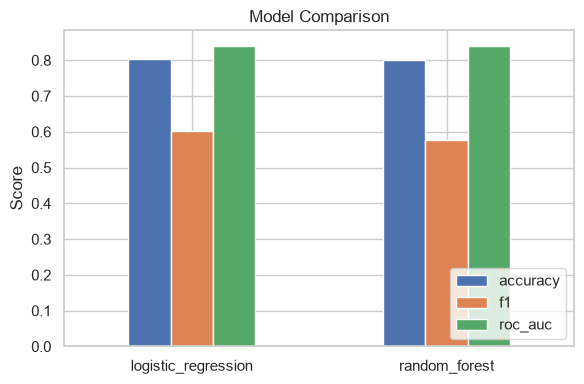

,accuracy,f1,roc_auc
logistic_regression,0.804826,0.603175,0.841125
random_forest,0.799858,0.577844,0.838545


In [8]:
metrics_df = pd.DataFrame({k: {m: v[m] for m in ["accuracy", "f1", "roc_auc"]} for k, v in results.items()}).T
metrics_df.plot(kind="bar", figsize=(6, 4), rot=0)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
metrics_df

## Export the Pipeline

In [9]:
joblib.dump(best_overall, "churn_pipeline.joblib")
print("Saved pipeline to churn_pipeline.joblib")

Saved pipeline to churn_pipeline.joblib


## Final Summary / Insights

- Wrapping preprocessing and modeling in a single `Pipeline` prevents data leakage during cross-validation and makes the exported artifact directly usable on raw, unprocessed input.
- **Logistic Regression** slightly outperformed Random Forest on F1 for the minority (churn) class, despite being the simpler model — a reminder to always benchmark against strong linear baselines.
- Both models reach ~80% accuracy but the churn-class F1 (~0.6) shows the harder-to-predict minority class deserves more attention (e.g. class weighting, SMOTE) in a production iteration.
- The exported `churn_pipeline.joblib` is a single, self-contained object — no separate scaler/encoder files to track — demonstrating production-readiness.